# CASF Eval on LASA


Evaluate the copied S-shape checkpoint trained on demos 0..5 against the held-out test demo 6. The notebook reports masked Frechet distance, maximum penetration depth, and integrated violation for SFP and CASF, then plots the two rollouts.


In [24]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd


def find_repo_root(start: Path = Path.cwd()) -> Path:
    for path in (start, *start.parents):
        if (path / 'casf' / 'lasa_test.py').is_file():
            return path
    raise FileNotFoundError('Could not find Constraining-Streaming-Flow-Models repo root')


REPO = find_repo_root()
for path in (REPO, REPO / 'casf'):
    path_str = str(path)
    if path_str not in sys.path:
        sys.path.insert(0, path_str)

from casf.lasa_test import (
    LasaFoldTestDataset,
    MethodConfig,
    collision_metrics,
    compute_fold_stats,
    default_device,
    import_legacy_modules,
    import_torch,
    load_lasa_demos,
    load_policy,
    make_obstacle,
    masked_discrete_frechet,
    rollout_policy,
)

TASK = 'Sshape'
TRAIN_DEMO_INDICES = list(range(6))
TEST_DEMO_INDEX = 6
NUM_DEMOS = 7

DATA_DIR = REPO / 'data' / 'lasa'
CKPT_PATH = REPO / 'models' / 'CASF_lasaTask_ah8_Sshape_sfpdObs_1000ep_lr0.0001_obsDim4_demo6-1_norm.pth'
OUT_DIR = REPO / 'outputs' / 'casf_eval_lasa'
OUT_DIR.mkdir(parents=True, exist_ok=True)

PRED_HORIZON = 16
OBS_HORIZON = 2
ACTION_HORIZON = 8
OBS_DIM = 4
ACTION_DIM = 2
ROLLOUT_FACTOR = 1.2
MIN_COMPLETION_FRAC = 0.9
EPS = 1e-6
DEVICE = default_device()

CASF_CONFIG = MethodConfig('casf', 'obstacle', 10.0, 0.01, 30.0, 0.02, EPS)

print('repo:', REPO)
print('data:', DATA_DIR / f'{TASK}.mat')
print('checkpoint:', CKPT_PATH)
print('train demos:', TRAIN_DEMO_INDICES)
print('test demo:', TEST_DEMO_INDEX)
print('device:', DEVICE)


repo: /home/loongo/Projects/Research/shared/baselines/Constraining-Streaming-Flow-Models
data: /home/loongo/Projects/Research/shared/baselines/Constraining-Streaming-Flow-Models/data/lasa/Sshape.mat
checkpoint: /home/loongo/Projects/Research/shared/baselines/Constraining-Streaming-Flow-Models/models/CASF_lasaTask_ah8_Sshape_sfpdObs_1000ep_lr0.0001_obsDim4_demo6-1_norm.pth
train demos: [0, 1, 2, 3, 4, 5]
test demo: 6
device: cuda


In [25]:
torch = import_torch()
device = torch.device(DEVICE)
(
    ConditionalUnet1D,
    _DatasetCls,
    StreamingFlowPolicyDeterministic,
    _shape_velocity_batch_metric_CASF,
    _shape_velocity_batch_hardBarrier,
    _shape_velocity_batch_CBF,
) = import_legacy_modules()

if not CKPT_PATH.is_file():
    raise FileNotFoundError(f'Missing checkpoint: {CKPT_PATH}')

mat_path = DATA_DIR / f'{TASK}.mat'
if not mat_path.is_file():
    raise FileNotFoundError(f'Missing LASA data: {mat_path}')

demos = load_lasa_demos(mat_path)[:NUM_DEMOS]
stats = compute_fold_stats(demos, TRAIN_DEMO_INDICES)
test_ds = LasaFoldTestDataset(
    demos,
    test_indices=[TEST_DEMO_INDEX],
    stats=stats,
    pred_horizon=PRED_HORIZON,
    obs_horizon=OBS_HORIZON,
    obs_dim=OBS_DIM,
)
test_demo = test_ds[0]
gt = np.asarray(test_demo['action'], dtype=np.float32)
obstacle = make_obstacle(TASK, radius_scale=0.15)

policy = load_policy(
    CKPT_PATH,
    device=device,
    ConditionalUnet1D=ConditionalUnet1D,
    StreamingFlowPolicyDeterministic=StreamingFlowPolicyDeterministic,
    pred_horizon=PRED_HORIZON,
    obs_horizon=OBS_HORIZON,
    obs_dim=OBS_DIM,
    action_dim=ACTION_DIM,
)

sfp_rollout = rollout_policy(
    policy,
    test_demo,
    device=device,
    action_horizon=ACTION_HORIZON,
    obs_horizon=OBS_HORIZON,
    rollout_factor=ROLLOUT_FACTOR,
    min_completion_frac=MIN_COMPLETION_FRAC,
    post_shaping=None,
    shaping_config=None,
)

casf_rollout = rollout_policy(
    policy,
    test_demo,
    device=device,
    action_horizon=ACTION_HORIZON,
    obs_horizon=OBS_HORIZON,
    rollout_factor=ROLLOUT_FACTOR,
    min_completion_frac=MIN_COMPLETION_FRAC,
    post_shaping=CASF_CONFIG.post_shaping,
    shaping_config=obstacle.shaping_dict(CASF_CONFIG),
)

print('loaded checkpoint and rolled out SFP/CASF on held-out demo', int(test_demo['demo_idx']))


number of parameters: 6.368615e+07
loaded checkpoint and rolled out SFP/CASF on held-out demo 6


In [26]:
def eval_metrics(name, rollout):
    traj = np.asarray(rollout['trajectory'], dtype=np.float32)
    collisions = collision_metrics(traj, obstacle.center_norm, obstacle.radius_norm)
    return {
        'method': name,
        'demo_idx': int(test_demo['demo_idx']),
        'valid_rollout': bool(rollout['valid']),
        'MaskedFD': masked_discrete_frechet(traj, gt, obstacle.center_norm, obstacle.radius_norm),
        'MPD': collisions['max_pen_depth'],
        'IntV': collisions['int_violation'],
    }

metrics_df = pd.DataFrame([
    eval_metrics('SFP', sfp_rollout),
    eval_metrics('CASF', casf_rollout),
])
metrics_path = OUT_DIR / f'{TASK.lower()}_demo{TEST_DEMO_INDEX:02d}_metrics.csv'
metrics_df.to_csv(metrics_path, index=False)
print('metrics saved:', metrics_path)
display(metrics_df)


metrics saved: /home/loongo/Projects/Research/shared/baselines/Constraining-Streaming-Flow-Models/outputs/casf_eval_lasa/sshape_demo06_metrics.csv


,method,demo_idx,valid_rollout,MaskedFD,MPD,IntV
0,SFP,6,True,0.238387,0.228486,9.479489
1,CASF,6,True,0.256669,0.010378,0.390195


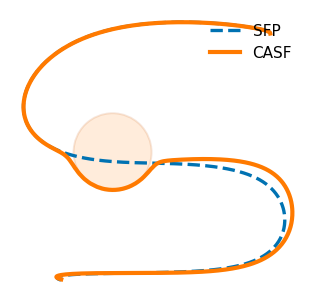

plot saved: /home/loongo/Projects/Research/shared/baselines/Constraining-Streaming-Flow-Models/outputs/casf_eval_lasa/sshape_demo06_rollout.png


In [34]:
import matplotlib.pyplot as plt
from IPython.display import display

plot_path = OUT_DIR / f'{TASK.lower()}_demo{TEST_DEMO_INDEX:02d}_rollout.png'

fig, ax = plt.subplots(figsize=(3,3))
ax.add_patch(
    plt.Circle(
        obstacle.center_norm,
        obstacle.radius_norm,
        facecolor='#FF7A00',
        edgecolor='#C45100',
        alpha=0.14,
        linewidth=1.4,
    )
)

sfp_traj = np.asarray(sfp_rollout['trajectory'], dtype=np.float32)
casf_traj = np.asarray(casf_rollout['trajectory'], dtype=np.float32)
ax.plot(sfp_traj[:, 0], sfp_traj[:, 1], color='#0072B2', linestyle='--', linewidth=2.4, label='SFP')
ax.plot(casf_traj[:, 0], casf_traj[:, 1], color='#FF7A00', linestyle='-', linewidth=3.0, label='CASF')

ax.set_aspect('equal', adjustable='box')
ax.grid(False)
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)
ax.legend(loc='upper right', frameon=False, fontsize=11)
fig.tight_layout(pad=0.15)
fig.savefig(plot_path, dpi=220, bbox_inches='tight', pad_inches=0.02)
plt.show()
plt.close(fig)

print('plot saved:', plot_path)


## CASF Parameter Sweep

Search CASF parameters on the held-out LASA demo. The selected config is the valid rollout with `MPD = 0` and `IntV = 0` within `ZERO_TOL`, then lowest `MaskedFD`.


In [ ]:
import itertools

SWEEP_ALPHAS = [1.0, 3.0, 5.0, 10.0, 20.0, 30.0, 50.0]
SWEEP_BETAS = [0.0, 0.001, 0.01]
SWEEP_W_SCALES = [10.0, 20.0, 30.0, 40.0, 50.0, 70.0]
SWEEP_DRIFT_GAINS = [0.0]
ZERO_TOL = 1e-10

sweep_rows = []
sweep_total = len(SWEEP_ALPHAS) * len(SWEEP_BETAS) * len(SWEEP_W_SCALES) * len(SWEEP_DRIFT_GAINS)
print(f'running CASF sweep over {sweep_total} configs on demo {TEST_DEMO_INDEX}')

for alpha, beta, w_scale, drift_gain in itertools.product(
    SWEEP_ALPHAS,
    SWEEP_BETAS,
    SWEEP_W_SCALES,
    SWEEP_DRIFT_GAINS,
):
    cfg = MethodConfig('casf', 'obstacle', alpha, beta, w_scale, drift_gain, EPS)
    rollout = rollout_policy(
        policy,
        test_demo,
        device=device,
        action_horizon=ACTION_HORIZON,
        obs_horizon=OBS_HORIZON,
        rollout_factor=ROLLOUT_FACTOR,
        min_completion_frac=MIN_COMPLETION_FRAC,
        post_shaping=cfg.post_shaping,
        shaping_config=obstacle.shaping_dict(cfg),
    )
    traj = np.asarray(rollout['trajectory'], dtype=np.float32)
    collisions = collision_metrics(traj, obstacle.center_norm, obstacle.radius_norm)
    sweep_rows.append({
        'alpha': alpha,
        'beta': beta,
        'w_scale': w_scale,
        'drift_gain': drift_gain,
        'valid_rollout': bool(rollout['valid']),
        'MaskedFD': masked_discrete_frechet(traj, gt, obstacle.center_norm, obstacle.radius_norm),
        'MPD': collisions['max_pen_depth'],
        'IntV': collisions['int_violation'],
        'steps': int(rollout['steps_taken']),
    })

sweep_df = pd.DataFrame(sweep_rows)
sweep_path = OUT_DIR / f'{TASK.lower()}_demo{TEST_DEMO_INDEX:02d}_casf_sweep.csv'
sweep_df.to_csv(sweep_path, index=False)

safe_df = sweep_df[
    sweep_df['valid_rollout']
    & (sweep_df['MPD'].abs() <= ZERO_TOL)
    & (sweep_df['IntV'].abs() <= ZERO_TOL)
    & sweep_df['MaskedFD'].notna()
].copy()

if safe_df.empty:
    best_casf_sweep = sweep_df.sort_values(['MPD', 'IntV', 'MaskedFD'], ascending=True).iloc[0]
    print(f'No config reached MPD=0 and IntV=0 within ZERO_TOL={ZERO_TOL}.')
    print('Showing nearest-safe config by MPD, IntV, then MaskedFD.')
else:
    best_casf_sweep = safe_df.sort_values('MaskedFD', ascending=True).iloc[0]
    print(f'Found {len(safe_df)} zero-violation configs within ZERO_TOL={ZERO_TOL}.')

print('sweep saved:', sweep_path)
print('best config:')
display(best_casf_sweep.to_frame().T)

print('top zero-violation configs by MaskedFD:')
display(safe_df.sort_values('MaskedFD').head(10) if not safe_df.empty else sweep_df.sort_values(['MPD', 'IntV', 'MaskedFD']).head(10))


running CASF sweep over 126 configs on demo 6
